<a href="https://colab.research.google.com/github/KaabiHiba/FER-CE-Project/blob/main/CNN%2BLLM_V1_Hiba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
BASE_PATH = "/content/drive/MyDrive/compound"
IMAGE_PATH = os.path.join(BASE_PATH, "Image/aligned")
LABEL_PATH = os.path.join(BASE_PATH, "EmoLabel/list_patition_label.txt")

labels_dict = {}

with open(LABEL_PATH, "r") as f:
    for line in f:
        name, label = line.strip().split()
        labels_dict[name] = int(label) - 1  # 🔥 start from 0

In [18]:
train_images = []
test_images = []

for name in labels_dict.keys():
    if "train" in name:
        train_images.append(name)
    else:
        test_images.append(name)

print(len(train_images), len(test_images))

3162 792


In [19]:
class EmotionDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        real_name = img_name.replace(".jpg", "_aligned.jpg")

        img_path = os.path.join(IMAGE_PATH, real_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = labels_dict[img_name]

        return image, label

In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [21]:
train_data, val_data = train_test_split(train_images, test_size=0.2, random_state=42)

train_dataset = EmotionDataset(train_data, transform=train_transform)
val_dataset = EmotionDataset(val_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, drop_last=True, num_workers=2)

In [22]:
labels_array = [labels_dict[x] for x in train_data]

num_classes = 14
class_weights = np.ones(num_classes)

unique_classes = np.unique(labels_array)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=labels_array
)

for i, c in enumerate(unique_classes):
    class_weights[c] = computed_weights[i]

weights = torch.tensor(class_weights, dtype=torch.float)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


In [24]:
model = models.resnet18(weights="DEFAULT")

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(512, 14)
)

model = model.to(device)

In [25]:
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [26]:
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [27]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=2,
    factor=0.3
)

In [28]:
num_epochs = 25
best_acc = 0

for epoch in range(num_epochs):
    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")

    model.train()
    running_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")

    # VALIDATION
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    print(f"✅ Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}%")

    scheduler.step(acc)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        print("🔥 Best model saved!")


🚀 Epoch 1/25
Batch 0/79 - Loss: 3.0322
Batch 20/79 - Loss: 2.4621
Batch 40/79 - Loss: 2.7003
Batch 60/79 - Loss: 2.5564
✅ Epoch 1 | Loss: 2.5669 | Acc: 20.23%
🔥 Best model saved!

🚀 Epoch 2/25
Batch 0/79 - Loss: 2.2814
Batch 20/79 - Loss: 2.1129
Batch 40/79 - Loss: 2.0617
Batch 60/79 - Loss: 2.3851
✅ Epoch 2 | Loss: 2.1888 | Acc: 23.52%
🔥 Best model saved!

🚀 Epoch 3/25
Batch 0/79 - Loss: 2.0251
Batch 20/79 - Loss: 1.7718
Batch 40/79 - Loss: 2.3724
Batch 60/79 - Loss: 1.7390
✅ Epoch 3 | Loss: 1.9921 | Acc: 27.96%
🔥 Best model saved!

🚀 Epoch 4/25
Batch 0/79 - Loss: 1.7873
Batch 20/79 - Loss: 1.8073
Batch 40/79 - Loss: 1.8444
Batch 60/79 - Loss: 1.8216
✅ Epoch 4 | Loss: 1.8271 | Acc: 28.12%
🔥 Best model saved!

🚀 Epoch 5/25
Batch 0/79 - Loss: 1.4680
Batch 20/79 - Loss: 1.7288
Batch 40/79 - Loss: 1.7011
Batch 60/79 - Loss: 1.8150
✅ Epoch 5 | Loss: 1.6807 | Acc: 29.93%
🔥 Best model saved!

🚀 Epoch 6/25
Batch 0/79 - Loss: 1.2756
Batch 20/79 - Loss: 1.9222
Batch 40/79 - Loss: 1.9604
Batch 

In [34]:
class_names = [
    "Neutral", "Happy", "Sad", "Surprise",
    "Fear", "Disgust", "Angry", "Contempt",
    "Happily Surprised", "Sadly Angry",
    "Sadly Surprised", "Fearfully Surprised",
    "Angrily Surprised", "Disgustedly Surprised"
]

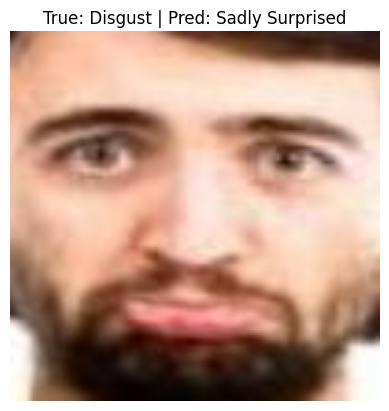

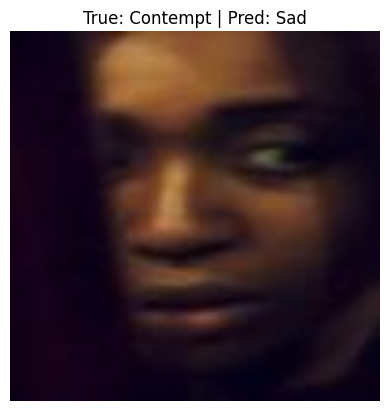

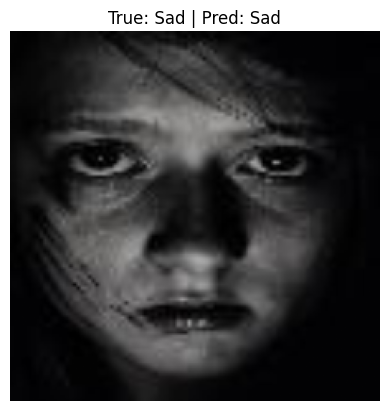

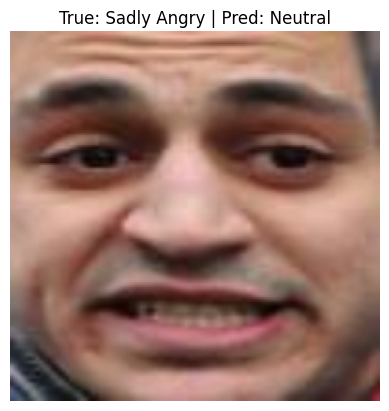

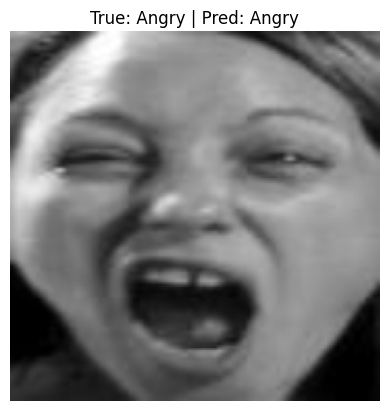

In [35]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

import matplotlib.pyplot as plt
import random

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    img_show = img.permute(1,2,0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5

    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()

In [36]:
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = val_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    return class_names[pred.item()]

In [32]:
img_path = "/content/drive/MyDrive/compound/Image/aligned/train_0001_aligned.jpg"
print("Emotion prédite :", predict_image(img_path))

Emotion prédite : Contempt


              precision    recall  f1-score   support

           0       0.60      0.59      0.60       100
           1       0.25      0.24      0.25        49
           2       0.24      0.22      0.23        23
           3       0.19      0.29      0.23        21
           4       0.17      0.06      0.09        17
           5       0.50      0.50      0.50       118
           6       0.42      0.74      0.54        19
           7       0.58      0.61      0.59        76
           8       0.28      0.24      0.26        29
           9       0.54      0.50      0.52       127
          10       0.15      0.17      0.16        29

    accuracy                           0.46       608
   macro avg       0.36      0.38      0.36       608
weighted avg       0.46      0.46      0.45       608



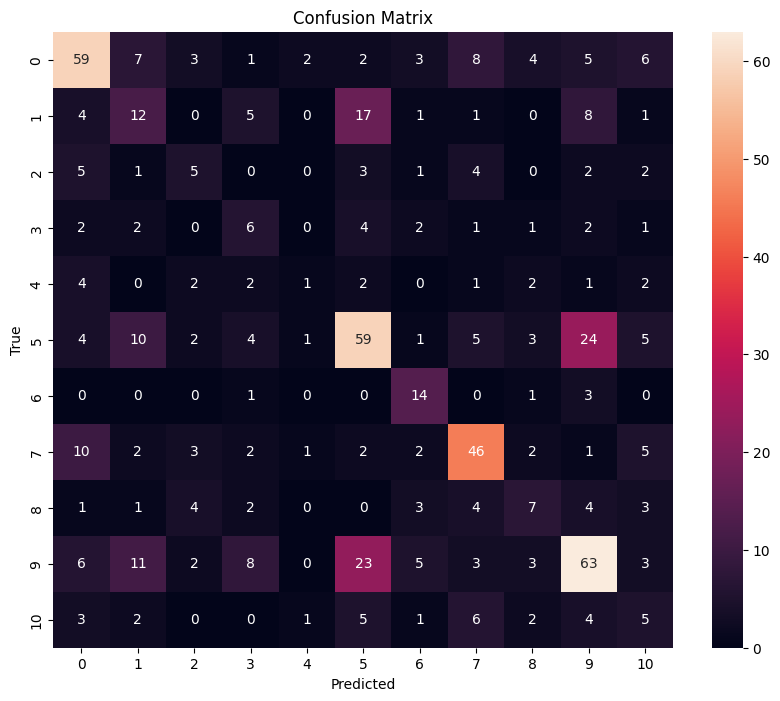

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Report
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [37]:
!pip install transformers accelerate

In [38]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("✅ BLIP model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP model loaded


In [43]:
from PIL import Image

def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")

    prompt = "Describe the facial emotion and explain the facial features (eyes, mouth, eyebrows)."

    inputs = processor(image, text=prompt, return_tensors="pt").to(device)

    out = blip_model.generate(**inputs, max_new_tokens=50)

    caption = processor.decode(out[0], skip_special_tokens=True)

    return caption

In [46]:
emotion_explanations = {
    "happily surprised": "smiling mouth and raised eyebrows",
    "sadly angry": "frowning eyebrows and tense lips",
    "fearfully disgusted": "wide eyes and wrinkled nose",
    "happily disgusted": "smile with slight nose wrinkle",
    "sadly fearful": "drooping eyes and slightly open mouth",
    "angrily surprised": "wide eyes with tense eyebrows",
    "sadly surprised": "raised eyebrows with sad mouth",
    "disgustedly surprised": "wrinkled nose and raised eyebrows",
    "fearfully surprised": "wide eyes and open mouth",
    "angrily disgusted": "tight lips and wrinkled nose",
    "sadly disgusted": "downturned lips and nose wrinkle",
    "happily angry": "smile with tense eyebrows",
    "fearfully angry": "wide eyes with tight lips",
    "neutral": "relaxed face with no strong emotion"
}

In [47]:
import matplotlib.pyplot as plt

def predict_with_explanation(img_path):

    image = Image.open(img_path).convert("RGB")

    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")
    plt.show()

    img = val_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    emotion = emotion_labels[pred.item()]
    explanation = emotion_explanations[emotion]

    print("😊 Emotion prédite :", emotion)
    print("🧠 Explication :", explanation)

In [44]:
//emotion_labels = [
    "happily surprised", "sadly angry", "fearfully disgusted",
    "happily disgusted", "sadly fearful", "angrily surprised",
    "sadly surprised", "disgustedly surprised",
    "fearfully surprised", "angrily disgusted",
    "sadly disgusted", "happily angry",
    "fearfully angry", "neutral"
]

import matplotlib.pyplot as plt

def predict_with_explanation(img_path):

    # 🔹 afficher image
    image = Image.open(img_path).convert("RGB")
    plt.imshow(image)
    plt.title("Image test")
    plt.axis("off")
    plt.show()

    # 🔹 CNN
    img = val_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    emotion = emotion_labels[pred.item()]

    # 🔹 LLM
    caption = generate_caption(img_path)

    print("😊 Emotion prédite :", emotion)
    print("🧠 Explication :", caption)

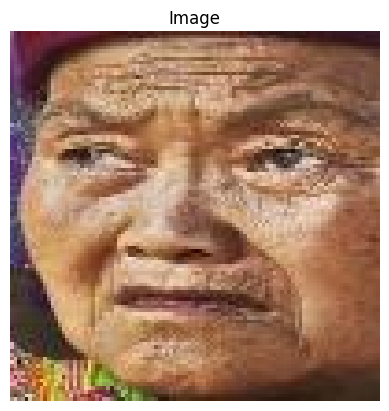

😊 Emotion prédite : disgustedly surprised
🧠 Explication : wrinkled nose and raised eyebrows


In [48]:
test_img = "/content/drive/MyDrive/compound/Image/aligned/train_0001_aligned.jpg"

predict_with_explanation(test_img)

In [49]:
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


In [50]:
import torch
import open_clip
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_clip, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model_clip = model_clip.to(device)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [71]:
text_prompts = [
    "a person smiling with raised eyebrows",
    "a person with angry eyebrows and sad mouth",
    "a person with wide eyes and disgusted face",
    "a smiling person with slight disgust",
    "a sad person with fearful eyes",
    "an angry person with surprised expression",
    "a sad person with raised eyebrows",
    "a disgusted person with surprised face",
    "a person with wide eyes and open mouth",
    "an angry person with disgust expression",
    "a sad person with disgust expression",
    "a smiling person with anger",
    "a fearful person with anger",
    "a neutral face"
]

In [73]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_clip_full(image_path):

    # 🔹 afficher image
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    plt.title("Image test")
    plt.axis("off")
    plt.show()

    # 🔹 preprocess
    image_input = preprocess(image).unsqueeze(0).to(device)
    text = open_clip.tokenize(text_prompts).to(device)

    with torch.no_grad():
        image_features = model_clip.encode_image(image_input)
        text_features = model_clip.encode_text(text)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        logits = (image_features @ text_features.T)
        probs = logits.softmax(dim=-1)

    pred = probs.argmax().item()

    # 🔥 extraire émotion propre
    emotion = text_prompts[pred]
    # nettoyer texte
    emotion_clean = emotion
    # explication simple
    explanation = "facial features suggest this emotion"
    # 🔥 explication simple
    explanation = emotion_explanations.get(emotion, "facial expression detected")

    print("😊 Emotion (CLIP) :", emotion)
    print("🧠 Explication :", explanation)
    print(probs.cpu().numpy())

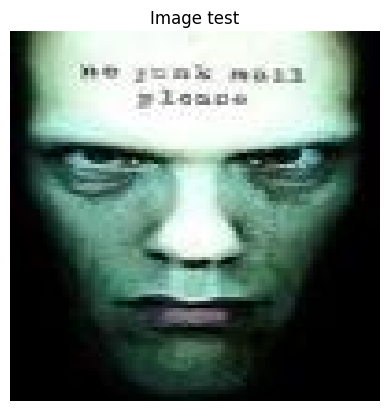

😊 Emotion (CLIP) : a fearful person with anger
🧠 Explication : facial expression detected
[[0.07048687 0.0716954  0.06992467 0.07095791 0.07181186 0.07115905
  0.07148643 0.0700992  0.07057943 0.07299207 0.07209732 0.07167634
  0.0732677  0.07176574]]


In [75]:
img_path = "/content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg"
predict_clip_full(img_path)